# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 452kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.64MB/s]


In [ ]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


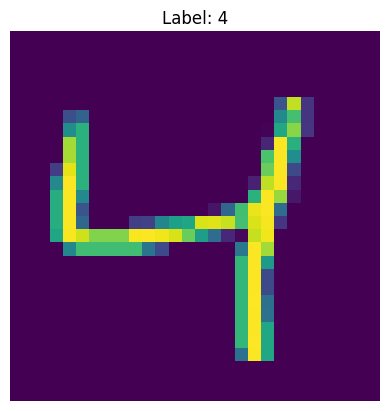

In [ ]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [ ]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [ ]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out =  self.fc4(out)
        return out

In [ ]:
# ANN 객체 생성
input_dim = 28*28 # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [ ]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs =model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.09784454852342606  Accuracy: 96.22494506835938 %
Iteration: 1000  Loss: 0.06879892945289612  Accuracy: 97.10060119628906 %
Iteration: 1500  Loss: 0.05519207566976547  Accuracy: 97.56761932373047 %
Iteration: 2000  Loss: 0.08528976142406464  Accuracy: 97.6649169921875 %
Iteration: 2500  Loss: 0.08017115294933319  Accuracy: 97.95680236816406 %
Iteration: 3000  Loss: 0.03856128081679344  Accuracy: 98.1513900756836 %
Iteration: 3500  Loss: 0.11131598055362701  Accuracy: 98.24868774414062 %
Iteration: 4000  Loss: 0.018394911661744118  Accuracy: 98.28760528564453 %
Iteration: 4500  Loss: 0.07472109794616699  Accuracy: 98.40435791015625 %


#### **ANN 학습 결과**

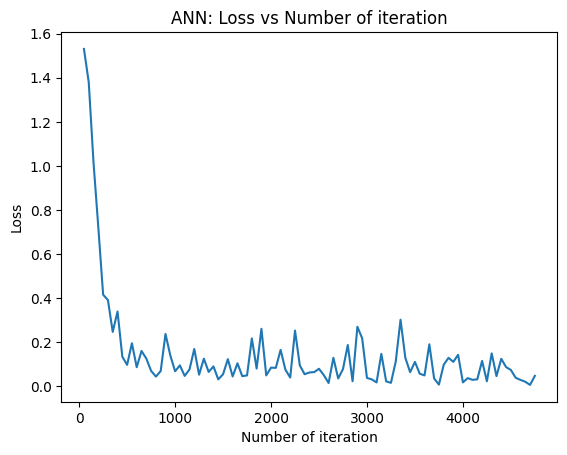

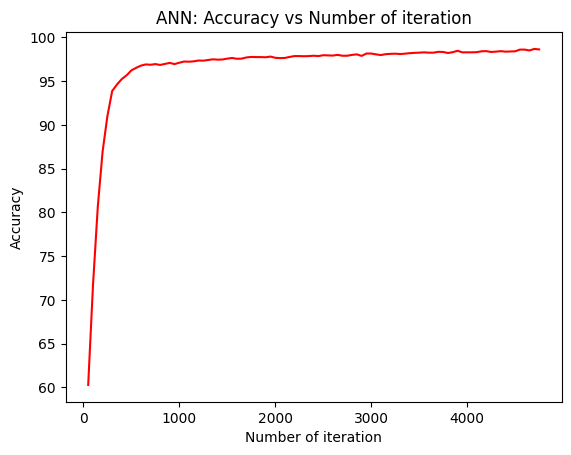

In [ ]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
- 학습 초기는 손실값 1.5, 정확도 60% 수준이었으나 반복하면서 빠르게 개선되었다.
-약 500회 반복시 정확도가 96% 대로 나타나 모델이 초기에 주요 특징을 빠르게 학습했음을 알 수 있다.
- 손실 그래프는 초반에 급격히 감소한 뒤 대체로 0에 가까운 낮은 범위를 유지했다.
- 일부 구간에서 손실값이 일시적으로 상승했는데, 이는 미니 배치마다 데이터의 구성과 난이도가 다르기 때문인 것으로 판단된다.
- 출력된 손실ㄷ 해당 시점의 "배치" 손실이므로 어느정도의 변동은 자연스럽다고 판단된다.
- 테스트 정확도가 지속적으로 상승하고 큰 폭으로 하락하지 않았으므로 overfitting 현상은 없는 것으로 파악된다.
- 단점이 있다면, 숫자 0~4만 분류하므로 MNIST전체 10개 클래스를 분류하는 문제보다 난도가 낮아 98.4% 정확도를 일반적인 MNIST 성능과 직접적으로 비교하기 어렵다고 판단된다.


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [ ]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
## 답안 ##

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# 실험 설정
input_dim = 28 * 28
output_dim = 5
hidden_dims = [50, 100, 150, 200]

num_epochs = 10
batch_size = 64
learning_rate = 0.02

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 실험 결과를 저장할 딕셔너리
loss_results = {}
accuracy_results = {}

for hidden_dim in hidden_dims:
    # 각 실험의 초기 조건을 동일하게 설정
    torch.manual_seed(42)

    # 데이터 셔플 순서를 실험마다 동일하게 설정
    generator = torch.Generator()
    generator.manual_seed(42)

    experiment_train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    # 모델, 손실함수, 옵티마이저 생성
    model = ANNModel(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim
    ).to(device)

    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate
    )

    epoch_loss_list = []
    epoch_accuracy_list = []

    for epoch in range(num_epochs):
        # 학습 모드
        model.train()

        total_loss = 0.0
        total_train_samples = 0

        for images, labels in experiment_train_loader:
            images = images.view(-1, input_dim).to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = loss_ftn(outputs, labels)

            loss.backward()
            optimizer.step()

            # epoch 평균 loss 계산을 위한 누적
            current_batch_size = labels.size(0)
            total_loss += loss.item() * current_batch_size
            total_train_samples += current_batch_size

        average_loss = total_loss / total_train_samples
        epoch_loss_list.append(average_loss)

        # 테스트 정확도 계산
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.view(-1, input_dim).to(device)
                labels = labels.to(device)

                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        epoch_accuracy_list.append(accuracy)

        print(
            f"Hidden Dimension: {hidden_dim:3d} | "
            f"Epoch: {epoch + 1:2d}/{num_epochs} | "
            f"Loss: {average_loss:.4f} | "
            f"Accuracy: {accuracy:.2f}%"
        )

    loss_results[hidden_dim] = epoch_loss_list
    accuracy_results[hidden_dim] = epoch_accuracy_list

Hidden Dimension:  50 | Epoch:  1/10 | Loss: 0.8117 | Accuracy: 96.19%
Hidden Dimension:  50 | Epoch:  2/10 | Loss: 0.1500 | Accuracy: 96.94%
Hidden Dimension:  50 | Epoch:  3/10 | Loss: 0.1170 | Accuracy: 97.43%
Hidden Dimension:  50 | Epoch:  4/10 | Loss: 0.1036 | Accuracy: 97.66%
Hidden Dimension:  50 | Epoch:  5/10 | Loss: 0.0952 | Accuracy: 97.37%
Hidden Dimension:  50 | Epoch:  6/10 | Loss: 0.0889 | Accuracy: 97.96%
Hidden Dimension:  50 | Epoch:  7/10 | Loss: 0.0827 | Accuracy: 95.86%
Hidden Dimension:  50 | Epoch:  8/10 | Loss: 0.0788 | Accuracy: 98.13%
Hidden Dimension:  50 | Epoch:  9/10 | Loss: 0.0734 | Accuracy: 98.19%
Hidden Dimension:  50 | Epoch: 10/10 | Loss: 0.0685 | Accuracy: 98.13%
Hidden Dimension: 100 | Epoch:  1/10 | Loss: 0.7690 | Accuracy: 96.17%
Hidden Dimension: 100 | Epoch:  2/10 | Loss: 0.1486 | Accuracy: 96.85%
Hidden Dimension: 100 | Epoch:  3/10 | Loss: 0.1188 | Accuracy: 97.43%
Hidden Dimension: 100 | Epoch:  4/10 | Loss: 0.1052 | Accuracy: 97.68%
Hidden

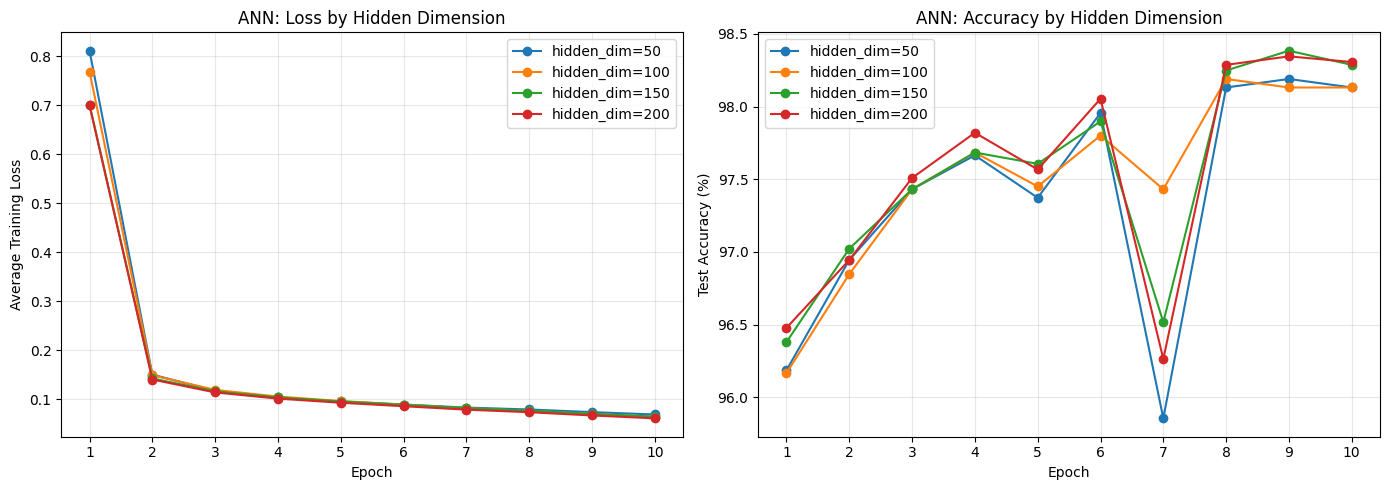

In [ ]:
# 실험 1 모델 학습 결과 시각화
## 답안 ##
# 결과 시각화
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Loss 비교
plt.subplot(1, 2, 1)

for hidden_dim in hidden_dims:
    plt.plot(
        epochs,
        loss_results[hidden_dim],
        marker="o",
        label=f"hidden_dim={hidden_dim}"
    )

plt.title("ANN: Loss by Hidden Dimension")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()

# Accuracy 비교
plt.subplot(1, 2, 2)

for hidden_dim in hidden_dims:
    plt.plot(
        epochs,
        accuracy_results[hidden_dim],
        marker="o",
        label=f"hidden_dim={hidden_dim}"
    )

plt.title("ANN: Accuracy by Hidden Dimension")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- 모든 hidden_dim 에서 학습이 진행될수록 loss가 감소하고 정확도가 상승하여 모델이 정상적으로 학습되었다
- 첫 epoch의 loss는 hidden_dim=50에서 0.8117, hidden_dim=200에서 0.7000으로, 은닉 차원이 클수록 초기 학습이 다소 빠르게 진행되었다. 이는 차원이 커질수록 뉴런과 파라미터가 많아져서 데이터의 특징을 더 잘 표현하기 때문인 것으로 판단된다.
- 최종 테스트 정확도는 각각 98.13%, 98.13%, 98.29%, 98.31%로 차이가 매우 작았습니다.
- 실험 중 가장 높은 정확도는 hidden_dim=150이 9번째 epoch에서 기록한 98.38%였으며, 가장 큰 200이 항상 최고 성능을 보이지는 않았다.
- 7번째 epoch에서 모든 모델의 정확도가 하락했는데, 미니 배치마다의 난도가 달라서 생긴 것으로 판단된다.
- 7번째 epoch 에서는 dim 50<200<150<100 순으로 정확도가 보여진다. 특히 dim 50이 가장 큰 낙폭을 보여주었다. 그 이유는 표현할 수 있는 특징의 수가 적기 때문에 변화에 민감하게 반응한 것으로 판단된다.
- 반면 dim 100은 현재 데이터에 필요한 표현 능력과 모델복잡도 사이 안정적인 상태에 도달하여 가장 적은 낙폭을 보여준 것으로 판단된다.
- 차원이 더 큰 150과 200은 표현 능력이 좋지만 파라미터가 많아서 변화에 더 민감하게 반응했을 수도 있다고 판단된다.
- 그러나 8번째 epoch에서 모델 정확도가 다시 98% 이상으로 회복되어, 7번째 결과는 일시적인 하락으로 보여진다.

In [ ]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
## 답안 ##
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# 고정 하이퍼파라미터
input_dim = 28 * 28
hidden_dim = 150
output_dim = 5

num_epochs = 10
batch_size = 64

# 비교할 learning rate
learning_rates = [0.1, 0.05, 0.02, 0.01, 0.005]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 실험 결과 저장
lr_loss_results = {}
lr_accuracy_results = {}

for learning_rate in learning_rates:
    # 모든 실험의 초기 가중치를 동일하게 설정
    torch.manual_seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # 모든 실험의 데이터 셔플 순서를 동일하게 설정
    generator = torch.Generator()
    generator.manual_seed(42)

    experiment_train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    # 모델 생성
    model = ANNModel(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim
    ).to(device)

    loss_ftn = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate
    )

    epoch_loss_list = []
    epoch_accuracy_list = []

    for epoch in range(num_epochs):
        # 학습 단계
        model.train()

        total_loss = 0.0
        total_train_samples = 0

        for images, labels in experiment_train_loader:
            images = images.view(-1, input_dim).to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = loss_ftn(outputs, labels)

            loss.backward()
            optimizer.step()

            current_batch_size = labels.size(0)
            total_loss += loss.item() * current_batch_size
            total_train_samples += current_batch_size

        # 해당 epoch의 평균 loss
        average_loss = total_loss / total_train_samples
        epoch_loss_list.append(average_loss)

        # 테스트 정확도 계산
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.view(-1, input_dim).to(device)
                labels = labels.to(device)

                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        epoch_accuracy_list.append(accuracy)

        print(
            f"Learning Rate: {learning_rate:5.3f} | "
            f"Epoch: {epoch + 1:2d}/{num_epochs} | "
            f"Loss: {average_loss:.4f} | "
            f"Accuracy: {accuracy:.2f}%"
        )

    lr_loss_results[learning_rate] = epoch_loss_list
    lr_accuracy_results[learning_rate] = epoch_accuracy_list

Learning Rate: 0.100 | Epoch:  1/10 | Loss: 0.2467 | Accuracy: 97.66%
Learning Rate: 0.100 | Epoch:  2/10 | Loss: 0.0875 | Accuracy: 96.69%
Learning Rate: 0.100 | Epoch:  3/10 | Loss: 0.0611 | Accuracy: 98.60%
Learning Rate: 0.100 | Epoch:  4/10 | Loss: 0.0438 | Accuracy: 98.89%
Learning Rate: 0.100 | Epoch:  5/10 | Loss: 0.0323 | Accuracy: 98.91%
Learning Rate: 0.100 | Epoch:  6/10 | Loss: 0.0240 | Accuracy: 99.22%
Learning Rate: 0.100 | Epoch:  7/10 | Loss: 0.0185 | Accuracy: 99.26%
Learning Rate: 0.100 | Epoch:  8/10 | Loss: 0.0130 | Accuracy: 99.40%
Learning Rate: 0.100 | Epoch:  9/10 | Loss: 0.0095 | Accuracy: 99.38%
Learning Rate: 0.100 | Epoch: 10/10 | Loss: 0.0074 | Accuracy: 99.10%
Learning Rate: 0.050 | Epoch:  1/10 | Loss: 0.3680 | Accuracy: 97.20%
Learning Rate: 0.050 | Epoch:  2/10 | Loss: 0.1064 | Accuracy: 97.16%
Learning Rate: 0.050 | Epoch:  3/10 | Loss: 0.0872 | Accuracy: 98.09%
Learning Rate: 0.050 | Epoch:  4/10 | Loss: 0.0726 | Accuracy: 98.35%
Learning Rate: 0.050

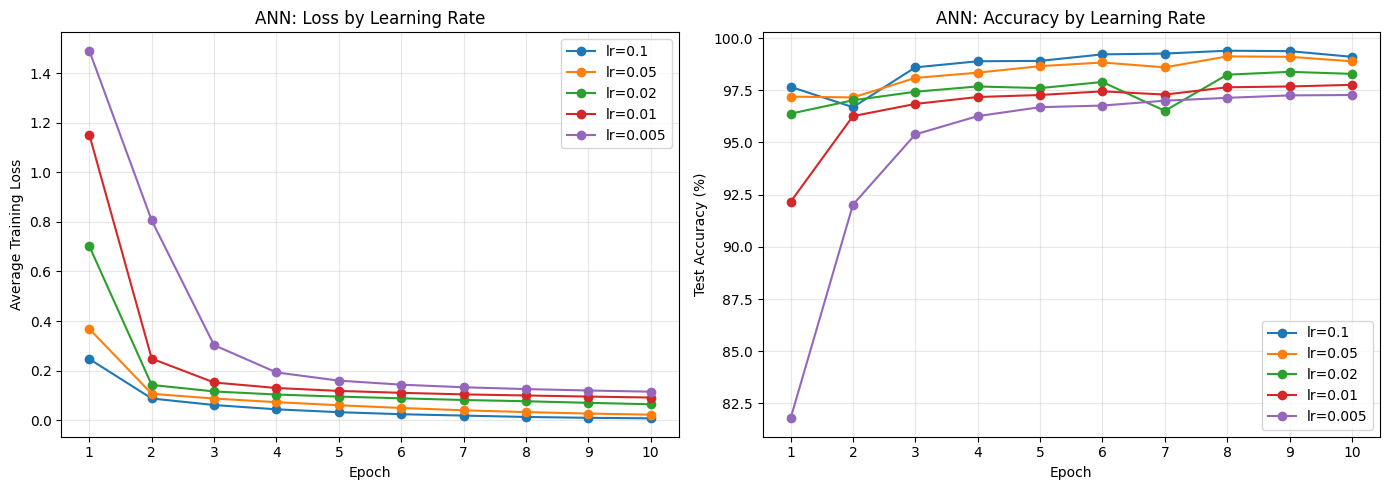

In [ ]:
# 실험 2 모델 학습 결과 시각화
## 답안 ##
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Learning rate별 loss
plt.subplot(1, 2, 1)

for learning_rate in learning_rates:
    plt.plot(
        epochs,
        lr_loss_results[learning_rate],
        marker="o",
        label=f"lr={learning_rate}"
    )

plt.title("ANN: Loss by Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()

# Learning rate별 accuracy
plt.subplot(1, 2, 2)

for learning_rate in learning_rates:
    plt.plot(
        epochs,
        lr_accuracy_results[learning_rate],
        marker="o",
        label=f"lr={learning_rate}"
    )

plt.title("ANN: Accuracy by Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- learning rate은 한번의 가중치 업데이트에서 모델이 이동하는 크기를 결정한다.
- lr=0.1은 첫 epoch부터 loss가 0.2467까지 감소하고 정확도 97.66%를 기록하여 가장 빠르게 학습되었다.
- lr=0.05도 비교적 빠르게 수렴했지만, 대부분의 epoch에서 lr=0.1보다 loss가 높고 정확도는 조금 낮았다.
- lr=0.02는 안정적으로 loss가 감소했으나 최종 정확도는 98.29%로 높은 학습률보다 낮았다
- lr=0.01과 lr=0.005는 가중치의 변화가 작아 초기 loss가 높고 정확도가 느리게 상승했다.
특히 lr=0.005는 첫 epoch 정확도가 81.79%였으며, 10번째 epoch에도 97.28%에 머물러 학습 속도가 가장 느렸다.
- 가장 높은 정확도는 lr=0.1이 8번째 epoch에서 기록한 99.40%로, 이번 실험에서는 lr=0.1의 성능이 가장 좋았다.
- 낮은 lr도 epoch 수를 늘리면 성능이 향상될 수 있다. 동일한 10 epoch 엥서는 비교적 높은 lr이 다소 유리하다고 판단된다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32 * 4 * 4, 5)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [26]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [27]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.5950253323684903
Epoch 2, Loss: 0.13204612453820064
Epoch 3, Loss: 0.10818328957281431
Epoch 4, Loss: 0.09321471006028152
Epoch 5, Loss: 0.08126340714615764
Epoch 6, Loss: 0.07221702120722795
Epoch 7, Loss: 0.0632353355876697
Epoch 8, Loss: 0.057025357113814755
Epoch 9, Loss: 0.05187737410751975
Epoch 10, Loss: 0.048216325481711945
Epoch 11, Loss: 0.04382229163039219
Epoch 12, Loss: 0.042040691626917315
Epoch 13, Loss: 0.03837401335106264
Epoch 14, Loss: 0.03607811643168455
Epoch 15, Loss: 0.03413852569277715
Epoch 16, Loss: 0.03293399732352851
Epoch 17, Loss: 0.031220321663089547
Epoch 18, Loss: 0.030837244783880068
Epoch 19, Loss: 0.030460257644595923
Epoch 20, Loss: 0.0275833597705682


#### **CNN 학습 결과**

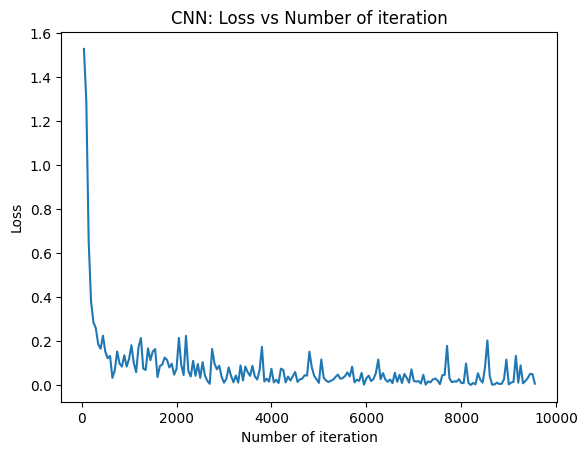

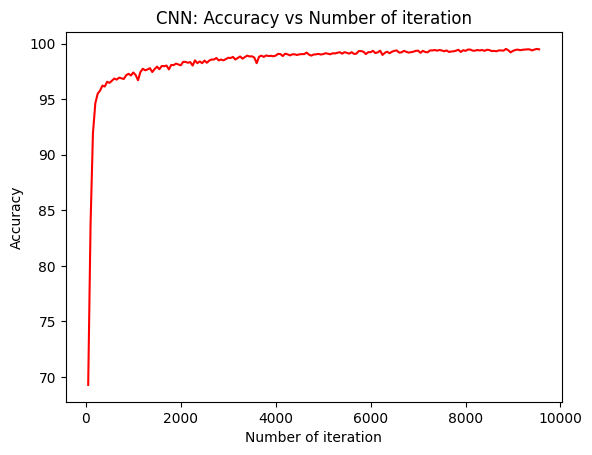

In [28]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
- ANN은 이미지를 1차원 벡터로 변환하여 학습했으며, 약 98~99%의 높은 분류 정확도를 보였다.  
- CNN은 합성곱과 풀링을 사용해 이미지의 공간적 특징을 추출했으며, 반복 횟수가 증가할수록 정확도가 약 99% 이상으로 상승했다.  
- CNN의 평균 loss는 첫 epoch의 0.5950에서 20번째 epoch의 0.0276까지 지속적으로 감소해 안정적인 학습 양상을 보였다.  
- 학습 초기에는 loss와 정확도의 변동이 있었지만, 이후 loss는 0에 가까워지고 정확도는 약 99.5% 수준으로 수렴했다.  
- 두 모델 모두 우수한 성능을 기록했지만, 이미지의 공간적 정보를 활용한 CNN이 최종 정확도와 loss 측면에서 더 좋은 결과를 보였다.